In [7]:
# IMPORTS

import os
import json
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")

TensorFlow : 2.21.0
Keras      : 3.13.2


In [8]:
# CONFIGURATION

MODEL_PATH     = Path(r"C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\vehicle_classifier_final.keras")
CLASS_JSON     = Path(r"C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\class_names.json")
INFERENCE_DIR  = Path(r"C:\Users\asus\OneDrive\Documents\AI DOE\test")

# Inference settings
N_IMAGES   = 5     # Images per run
SHOW_TOP_K = 3     # Top-K predictions shown per image
FORCE_SEED = None  # Set to an integer to repeat a specific batch, e.g. FORCE_SEED = 42

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

print("Configuration set.")

Configuration set.


In [9]:
# LOAD MODEL AND CLASS NAMES

for label, path in [("Model file", MODEL_PATH),
                     ("Class JSON", CLASS_JSON),
                     ("Test folder", INFERENCE_DIR)]:
    status = "✓ Found" if path.exists() else "✗ NOT FOUND"
    print(f"  {status} — {label}: {path}")

print()

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model not found at:\n  {MODEL_PATH}\n"
        "Run the training notebook first to generate the saved model."
    )

if not CLASS_JSON.exists():
    raise FileNotFoundError(
        f"class_names.json not found at:\n  {CLASS_JSON}\n"
        "Run the training notebook first."
    )

with open(CLASS_JSON, 'r') as f:
    class_map = json.load(f)

CLASS_NAMES = class_map['class_names']
IMG_SIZE    = class_map['img_size']
NUM_CLASSES = class_map['num_classes']

print(f"Classes loaded  : {NUM_CLASSES}")
print(f"Image size      : {IMG_SIZE} × {IMG_SIZE}")
print(f"Class list      : {CLASS_NAMES}")
print()

print("Loading model... (may take a few seconds on first load)")
model = keras.models.load_model(MODEL_PATH)
print(f"Model loaded successfully.")
print(f"  Input  shape : {model.input_shape}")
print(f"  Output shape : {model.output_shape}")

  ✓ Found — Model file: C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\vehicle_classifier_final.keras
  ✓ Found — Class JSON: C:\Users\asus\OneDrive\Documents\AI DOE\saved_models\class_names.json
  ✓ Found — Test folder: C:\Users\asus\OneDrive\Documents\AI DOE\test

Classes loaded  : 11
Image size      : 128 × 128
Class list      : ['articulated_truck', 'background', 'bicycle', 'bus', 'car', 'motorcycle', 'non-motorized_vehicle', 'pedestrian', 'pickup_truck', 'single_unit_truck', 'work_van']

Loading model... (may take a few seconds on first load)
Model loaded successfully.
  Input  shape : (None, 128, 128, 3)
  Output shape : (None, 11)


In [10]:
# COLLECT ALL IMAGES FROM INFERENCE FOLDER

if not INFERENCE_DIR.exists():
    raise FileNotFoundError(
        f"Inference folder not found:\n  {INFERENCE_DIR}\n"
        "Create the folder and add some vehicle images."
    )

all_images = sorted([
    p for p in INFERENCE_DIR.iterdir()
    if p.suffix.lower() in VALID_EXTENSIONS
])

if len(all_images) == 0:
    raise ValueError(
        f"No valid images found in:\n  {INFERENCE_DIR}\n"
        "Add .jpg or .png images and rerun."
    )

print(f"Inference folder : {INFERENCE_DIR}")
print(f"Total images     : {len(all_images)}")
print()
print("Ready. Run Cell 6 to classify a random batch.")
print("Re-run Cell 6 as many times as you want for new batches.")

Inference folder : C:\Users\asus\OneDrive\Documents\AI DOE\test
Total images     : 129795

Ready. Run Cell 6 to classify a random batch.
Re-run Cell 6 as many times as you want for new batches.


Seed: 99911  |  Set FORCE_SEED = 99911 in Cell 3 to repeat this batch

  RESULTS  (seed=99911, 5 images)

  [1] 874151766.jpg
       Top-1 → car                          54.94%  [MED]
       Top-2 → single_unit_truck            12.15%
       Top-3 → non-motorized_vehicle        10.09%

  [2] 479110534.jpg
       Top-1 → pickup_truck                 99.63%  [HIGH]
       Top-2 → car                          0.27%
       Top-3 → work_van                     0.09%

  [3] 909161451.jpg
       Top-1 → work_van                     44.33%  [LOW]
       Top-2 → articulated_truck            41.68%
       Top-3 → single_unit_truck            6.26%

  [4] 188567053.jpg
       Top-1 → background                   93.29%  [HIGH]
       Top-2 → non-motorized_vehicle        6.22%
       Top-3 → articulated_truck            0.32%

  [5] 717568992.jpg
       Top-1 → background                   98.51%  [HIGH]
       Top-2 → non-motorized_vehicle        0.56%
       Top-3 → pedestrian                   

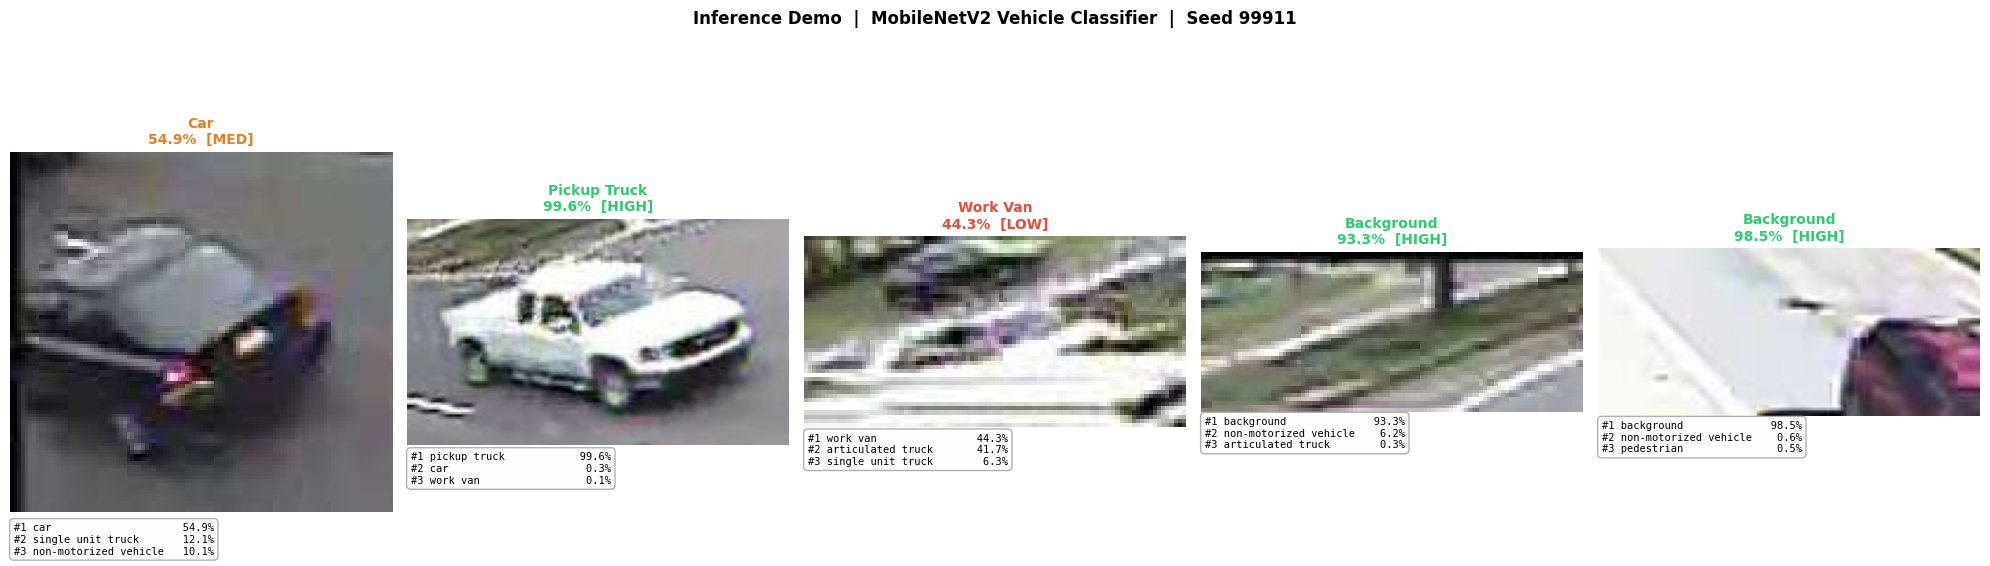


  Done. Re-run this cell for a new batch.


In [15]:
# ▶ RE-RUN THIS CELL FOR NEW BATCHES

run_seed = FORCE_SEED if FORCE_SEED is not None else int(time.time()) % 100_000
print(f"Seed: {run_seed}  |  Set FORCE_SEED = {run_seed} in Cell 3 to repeat this batch")

n_select = min(N_IMAGES, len(all_images))
selected = random.Random(run_seed).sample(all_images, k=n_select)

# PREPROCESS
def load_and_preprocess(img_path, size):
    """Load image from disk and resize to (size, size, 3) in [0, 1] float32."""
    raw = tf.io.read_file(str(img_path))
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [size, size])
    img = tf.cast(img, tf.float32) / 255.0
    return img.numpy()

batch = np.stack([load_and_preprocess(p, IMG_SIZE) for p in selected], axis=0)

# PREDICT
all_probs = model.predict(batch, verbose=0)   # shape: (n_select, 11)

# DISPLAY
ncols = min(n_select, 5)
nrows = (n_select + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 6))
axes = np.array(axes).reshape(nrows, ncols)

fig.suptitle(
    f"Inference Demo  |  MobileNetV2 Vehicle Classifier  |  Seed {run_seed}",
    fontsize=12, fontweight='bold', y=1.01
)

print("\n" + "=" * 65)
print(f"  RESULTS  (seed={run_seed}, {n_select} images)")
print("=" * 65)

for i, (img_path, probs) in enumerate(zip(selected, all_probs)):
    row, col = divmod(i, ncols)
    ax = axes[row, col]

    top_idx  = np.argsort(probs)[::-1][:SHOW_TOP_K]
    top_conf = probs[top_idx]

    top1_name = CLASS_NAMES[top_idx[0]]
    top1_conf = float(top_conf[0])

    if top1_conf >= 0.70:
        color, level = '#2ecc71', 'HIGH'
    elif top1_conf >= 0.45:
        color, level = '#e67e22', 'MED'
    else:
        color, level = '#e74c3c', 'LOW'

    try:
        display_img = plt.imread(str(img_path))
    except Exception:
        display_img = batch[i]
    ax.imshow(display_img)
    ax.axis('off')

    ax.set_title(
        f"{top1_name.replace('_', ' ').title()}\n"
        f"{top1_conf*100:.1f}%  [{level}]",
        fontsize=10, fontweight='bold', color=color, pad=6
    )

    lines = [
        f"#{r+1} {CLASS_NAMES[idx].replace('_', ' '):<22} {conf*100:5.1f}%"
        for r, (idx, conf) in enumerate(zip(top_idx, top_conf))
    ]
    ax.annotate(
        "\n".join(lines),
        xy=(0.01, -0.03), xycoords='axes fraction',
        fontsize=7.5, va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fefefe',
                  edgecolor='#aaaaaa', alpha=0.92)
    )

    print(f"\n  [{i+1}] {img_path.name}")
    print(f"       Top-1 → {top1_name:<28} {top1_conf*100:.2f}%  [{level}]")
    for r, (idx, conf) in enumerate(zip(top_idx[1:], top_conf[1:]), start=2):
        print(f"       Top-{r} → {CLASS_NAMES[idx]:<28} {conf*100:.2f}%")

for j in range(n_select, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis('off')

plt.tight_layout()
plt.savefig(
    MODEL_PATH.parent / f"demo_seed{run_seed}.png",
    dpi=150, bbox_inches='tight'
)
plt.show()

print("\n" + "=" * 65)
print("  Done. Re-run this cell for a new batch.")
print("=" * 65)